# Pipeline RGBT - Notebook 01: Pré-Transformação e Alinhamento Multimodal
**Projeto:** Contagem de Pessoas com Sensores Multimodais (RGB + Térmico LWIR)  
**Objetivo:** Este notebook é o primeiro estágio do pipeline. Ele recebe os pares de imagens brutas (*raw*) capturados pela câmera embarcada no drone, realiza a transformação das imagens gerando o insumo padronizado para o modelo no notebook **02_contagem_pessoas_rgbtcc**.


## 1. Setup do Ambiente e Estrutura de Diretórios
Importamos os módulos científicos fundamentais (`OpenCV`, `NumPy`, `Matplotlib`), configuramos os caminhos do projeto e garantimos interoperabilidade com a classe de produção `RGBTImageEqualizer` da pasta `app/`.


In [1]:
import os
import sys
import json
import time
from pathlib import Path

# Configurar diretório de cache do Matplotlib
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Resolução de diretórios do projeto
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == 'DEF-rgbtcc' else Path.cwd() / 'notebooks' / 'DEF-rgbtcc'
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = Path.cwd()

ROOT_DIR = NOTEBOOK_DIR.parent.parent if NOTEBOOK_DIR.parent.name == 'notebooks' else NOTEBOOK_DIR.parent
APP_DIR = ROOT_DIR / 'app'

# Adicionar app/ e NOTEBOOK_DIR ao sys.path
for p in [str(NOTEBOOK_DIR), str(ROOT_DIR), str(APP_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from head_counting.preprocessing import RGBTImageEqualizer

# Definir pastas do pipeline
input_candidates = [
    NOTEBOOK_DIR / 'input',
    NOTEBOOK_DIR.parent / 'input',
    APP_DIR / 'data' / 'landing',
    APP_DIR / 'data' / 'bronze' / 'images',
]
INPUT_DIR = next((p for p in input_candidates if p.exists() and (p / 'DJI_0789_W.JPG').exists()), NOTEBOOK_DIR / 'input')
OUTPUT_DIR = NOTEBOOK_DIR / 'output' / '01_pre_transformacao'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"[*] Diretório de Entrada (RAW):             {INPUT_DIR}")
print(f"[*] Diretório de Saída (Insumo Notebook 02): {OUTPUT_DIR}")


[*] Diretório de Entrada (RAW):             /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/input
[*] Diretório de Saída (Insumo Notebook 02): /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/01_pre_transformacao


## 2. Ingestão e Inspeção Visual das Imagens Brutas (RAW)
Lemos o par capturado pelo drone:
- `DJI_0789_W.JPG`: Imagem óptica de altíssima resolução (8000x6000 px) com lente grande-angular (24mm equivalente).
- `DJI_0790_T.JPG`: Imagem termográfica de onda longa (LWIR) com resolução nativa de 640x512 px e campo visual mais fechado.


[*] RGB RAW:     8000x6000 px | Proporção: 1.33
[*] Térmica RAW: 640x512 px | Proporção: 1.25


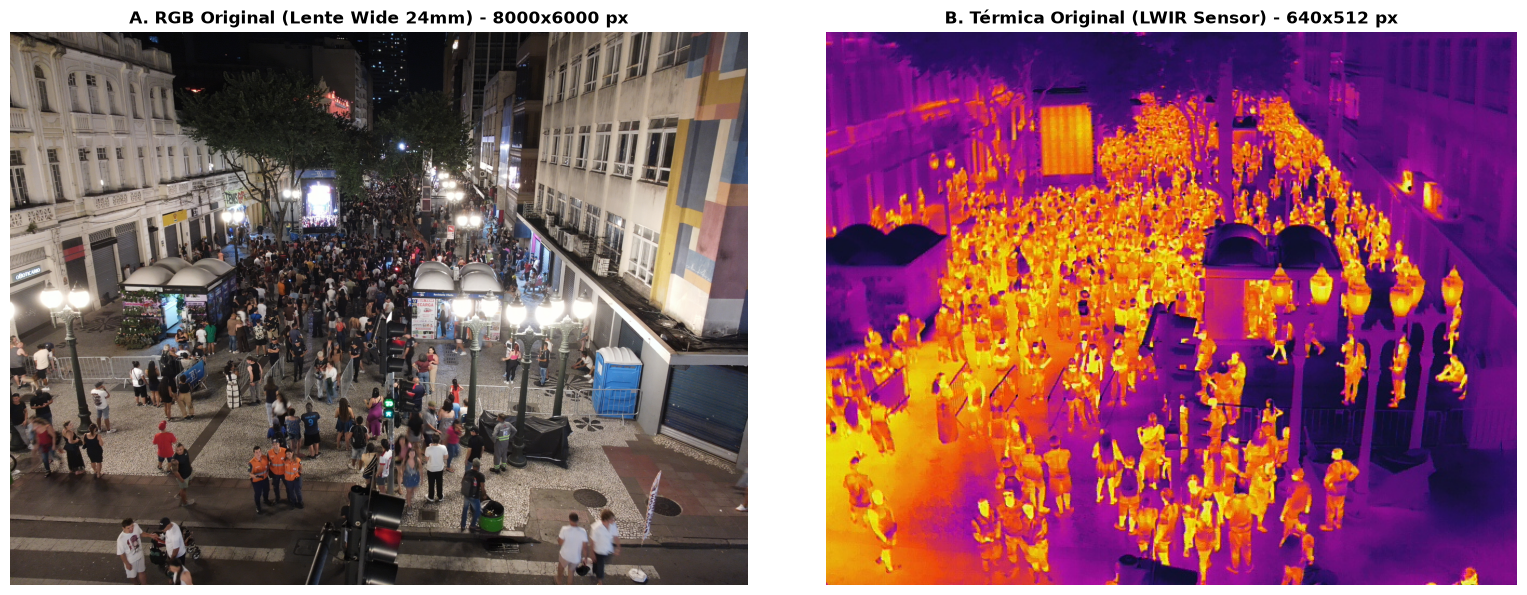

In [2]:
# Identificar arquivos de entrada
raw_rgb_path = INPUT_DIR / 'DJI_0789_W.JPG'
raw_th_path = INPUT_DIR / 'DJI_0790_T.JPG'

assert raw_rgb_path.exists(), f"Imagem RGB bruta não encontrada: {raw_rgb_path}"
assert raw_th_path.exists(), f"Imagem Térmica bruta não encontrada: {raw_th_path}"

# Carregamento com OpenCV (BGR)
img_rgb_raw_bgr = cv2.imread(str(raw_rgb_path))
img_th_raw_bgr = cv2.imread(str(raw_th_path))

# Conversão para RGB para exibição correta no matplotlib
img_rgb_raw = cv2.cvtColor(img_rgb_raw_bgr, cv2.COLOR_BGR2RGB)
img_th_raw = cv2.cvtColor(img_th_raw_bgr, cv2.COLOR_BGR2RGB)

h_rgb, w_rgb = img_rgb_raw.shape[:2]
h_th, w_th = img_th_raw.shape[:2]

print("=" * 60)
print(f"[*] RGB RAW:     {w_rgb}x{h_rgb} px | Proporção: {w_rgb/h_rgb:.2f}")
print(f"[*] Térmica RAW: {w_th}x{h_th} px | Proporção: {w_th/h_th:.2f}")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_rgb_raw)
axes[0].set_title(f"A. RGB Original (Lente Wide 24mm) - {w_rgb}x{h_rgb} px", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_th_raw)
axes[1].set_title(f"B. Térmica Original (LWIR Sensor) - {w_th}x{h_th} px", fontsize=12, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 3. Passo 1 - Correção de Distorção de Lente Grande-Angular (Undistortion)
A câmera óptica Wide possui curvatura esférica de barril. Aplicamos a matriz de calibração intrínseca $K$ e coeficientes radiais $D$ na imagem RAW completa de 8000x6000 px.

> Para a demonstração das equações polinomiais de Brown-Conrady e a prova de por que desdistorcer após o corte desloca o centro óptico em milhares de pixels, consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md` (Decisão 01: Desdistorção de Lente no Sensor RAW)](docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md#decisao-01-desdistorcao-de-lente-grande-angular-no-sensor-raw-completo)


[✓] Desdistorção de lente Wide concluída (8000x6000 px).


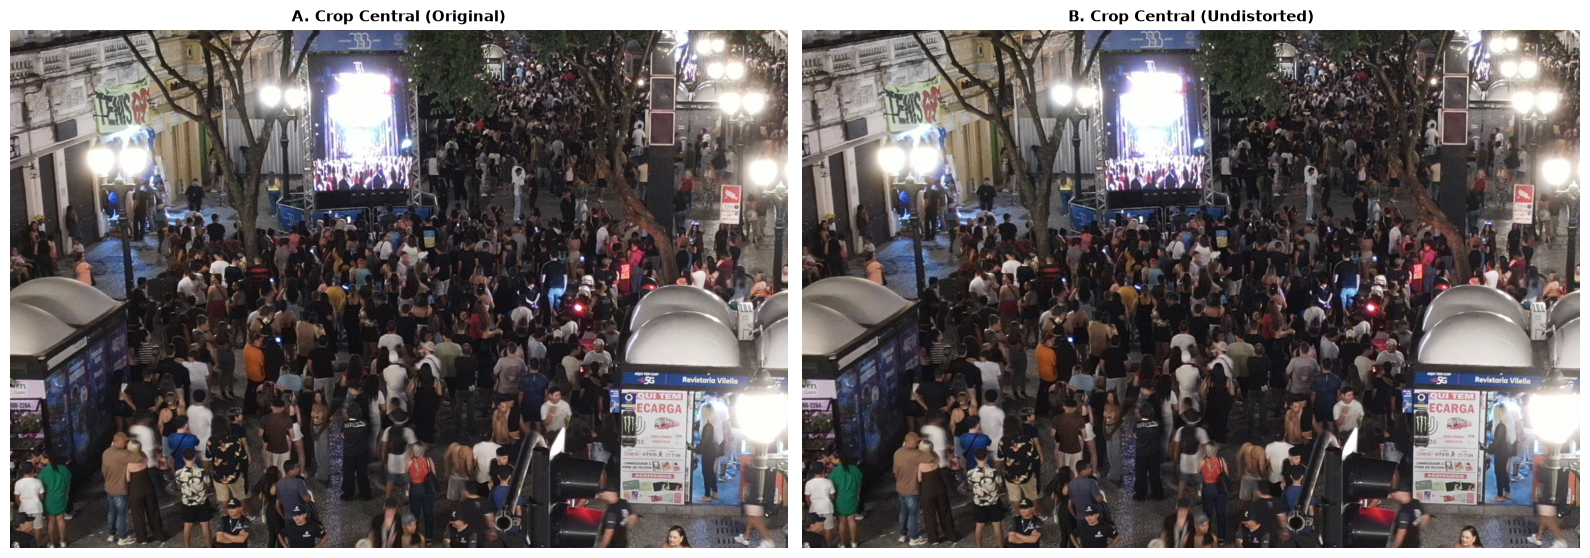

In [3]:
# Instanciar preprocessador com parâmetros padrão
eq = RGBTImageEqualizer(undistort_lens=True)

# Aplicação da desdistorção geométrica
img_rgb_undist = eq._undistort_wide_lens(img_rgb_raw)

h_raw, w_raw = img_rgb_raw.shape[:2]
print(f"[✓] Desdistorção de lente Wide concluída ({w_raw}x{h_raw} px).")

# Recorte dinâmico para visualização: se a imagem for full-res (ex: >=3500x5000), exibe crop central;
# se já for um recorte menor, exibe a imagem completa sem estourar os limites.
if h_raw >= 3500 and w_raw >= 5000:
    vis_raw = img_rgb_raw[1500:3500, 2000:5000]
    vis_undist = img_rgb_undist[1500:3500, 2000:5000]
    subtitulo = "Crop Central"
else:
    vis_raw = img_rgb_raw
    vis_undist = img_rgb_undist
    subtitulo = f"Imagem Completa ({w_raw}x{h_raw} px)"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(vis_raw)
axes[0].set_title(f"A. {subtitulo} (Original)", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(vis_undist)
axes[1].set_title(f"B. {subtitulo} (Undistorted)", fontsize=11, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 4. Passo 2 - Recorte de Campo de Visão (FOV Center Crop) Ancorado na Altura
A câmera térmica cobre aproximadamente os 70% centrais da altura da cena da câmera Wide.  
- Altura recortada: $	ext{crop\_h} = 6000 \cdot 0.70 = 4200	ext{ px}$
- Proporção 5:4 exata $\implies 	ext{crop\_w} = 4200 \cdot 1.25 = 5250	ext{ px}$

> Para a análise quantitativa do erro de zoom de 7% (que causava o ghost lateral de 18 px na mulher quando o corte era feito pela largura) e a comprovação da proporção 5:4 exata, consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md` (Decisão 02: Casamento de Campo de Visão Ancorado na Altura)](docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md#decisao-02-casamento-de-campo-de-visao-fov-center-crop-ancorado-na-altura)


[*] Resolução do Recorte de FOV RGB: 5250x4200 px
[*] Proporção de Aspecto (Aspect Ratio): 1.2500 (Exatamente 5:4 = 1.2500)


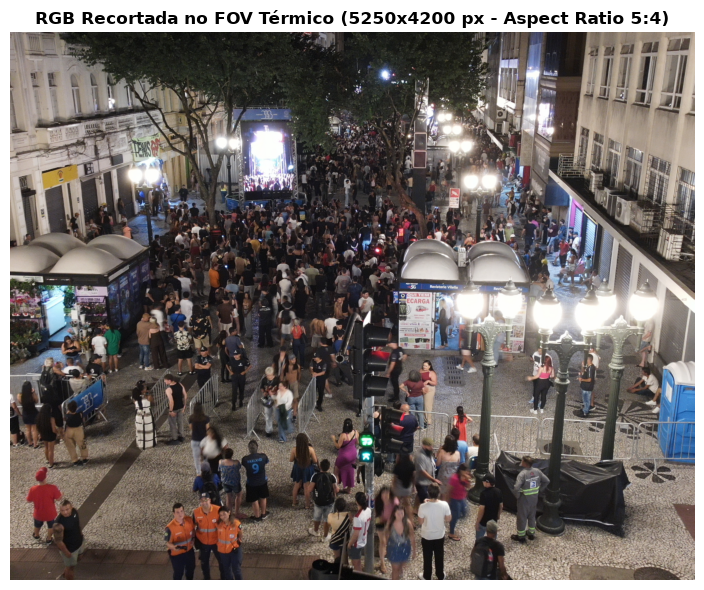

In [4]:
img_rgb_cropped = eq._fov_center_crop(img_rgb_undist)
h_crop, w_crop = img_rgb_cropped.shape[:2]

print("=" * 60)
print(f"[*] Resolução do Recorte de FOV RGB: {w_crop}x{h_crop} px")
print(f"[*] Proporção de Aspecto (Aspect Ratio): {w_crop / h_crop:.4f} (Exatamente 5:4 = 1.2500)")
print("=" * 60)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(img_rgb_cropped)
ax.set_title(f"RGB Recortada no FOV Térmico ({w_crop}x{h_crop} px - Aspect Ratio 5:4)", fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Passo 3 - Equalização Radiométrica Térmica (CLAHE no Espaço Lab)
Convertemos a imagem térmica para o espaço de cor **Lab** e aplicamos **CLAHE** (`clipLimit=2.5`, `grid=(8,8)`) estritamente no canal $L$ (luminância).

> Para a justificativa física sobre emissividade térmica de microbolômetros e a explicação de por que a equalização convencional estoura o ruído do asfalto, consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md` (Decisão 03: Equalização Radiométrica da Térmica)](docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md#decisao-03-equalizacao-radiometrica-da-termica-clahe-no-espaco-lab)


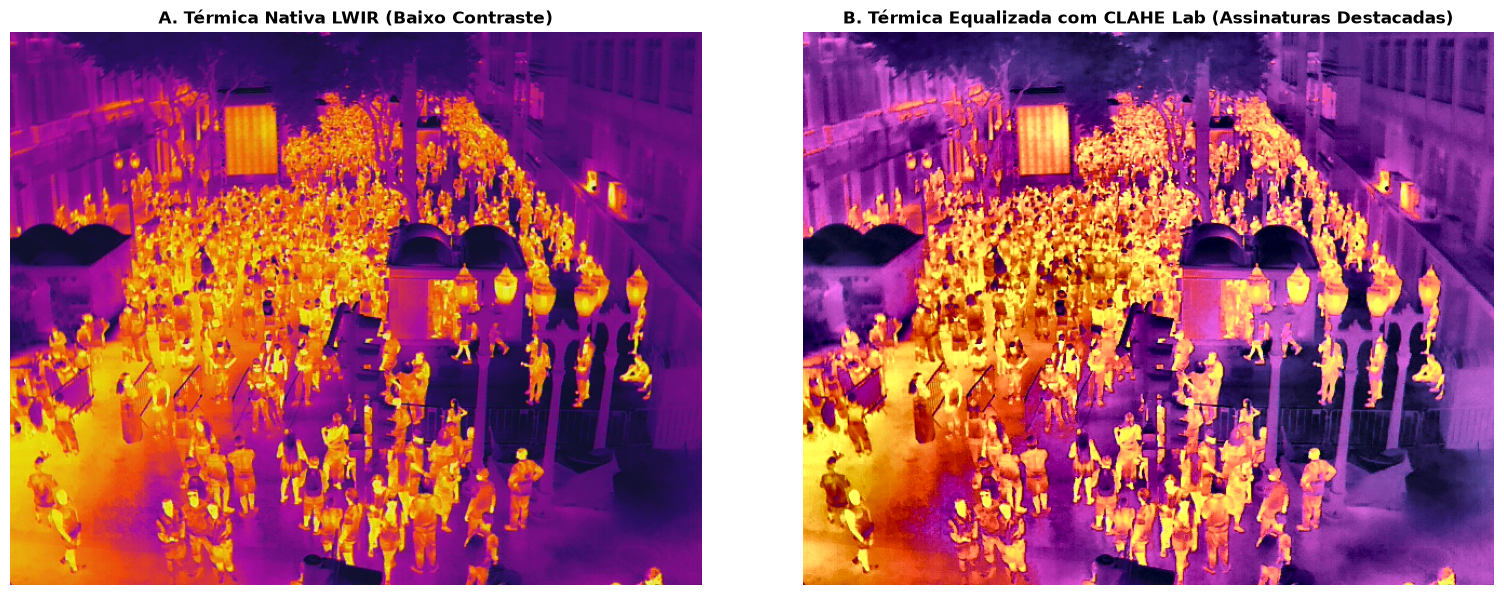

In [5]:
img_th_equalized = eq.enhance_thermal(img_th_raw)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_th_raw)
axes[0].set_title("A. Térmica Nativa LWIR (Baixo Contraste)", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_th_equalized)
axes[1].set_title("B. Térmica Equalizada com CLAHE Lab (Assinaturas Destacadas)", fontsize=12, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 6. Passo 4 - Padronização de Resolução ($1280 	imes 1024$) e Deslocamento Afim ($dx=-22, dy=-23$)
Reamostramos RGB e Térmica para a resolução padrão $1280 	imes 1024	ext{ px}$ (divisível por 32). Aplicamos a matriz afim $dx=-22	ext{ px}$ e $dy=-23	ext{ px}$ na imagem RGB para alinhar as silhuetas dos pedestres no plano do solo.

> Para a teoria de baseline estéreo em drones, a relação altitude/paralaxe $d = (f \cdot B)/Z$ e a justificativa de descarte de homografia dinâmica por SIFT/ORB, consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md` (Decisão 04: Padronização de Resolução e Compensação Afim)](docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md#decisao-04-padronizacao-de-resolucao-e-compensacao-afim-de-baseline-estereo)


In [6]:
# Redimensionamento padronizado para 1280x1024 (5:4)
img_rgb_resized = cv2.resize(img_rgb_cropped, (1280, 1024), interpolation=cv2.INTER_AREA)
img_th_resized = cv2.resize(img_th_equalized, (1280, 1024), interpolation=cv2.INTER_CUBIC)

# Matriz de translação afim para compensação estéreo de paralaxe (dx=-22, dy=-23)
M_shift = np.float32([[1, 0, eq.shift_rgb_x], [0, 1, eq.shift_rgb_y]])
img_rgb_aligned = cv2.warpAffine(
    img_rgb_resized,
    M_shift,
    (1280, 1024),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_REFLECT_101
)

print(f"[✓] Imagem RGB Transladada: dx = {eq.shift_rgb_x} px | dy = {eq.shift_rgb_y} px")
print(f"[✓] Resolução Final Alinhada: {img_rgb_aligned.shape[1]}x{img_rgb_aligned.shape[0]} px")


[✓] Imagem RGB Transladada: dx = -22 px | dy = -23 px
[✓] Resolução Final Alinhada: 1280x1024 px


## 7. Passo 5 - Validação Bit-a-Bit com a Classe de Produção (`RGBTImageEqualizer`)
Instanciamos a classe `RGBTImageEqualizer` do módulo oficial `app/` e comprovamos que o código deste notebook produz **exatamente os mesmos pixels** que o sistema de produção (diferença máxima de 0.00000 px).

> Para a governança de software, reprodutibilidade científica e eliminação do problema 'no meu notebook funciona e em produção não', consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md` (Decisão 05: Validação de Paridade Bit-a-Bit)](docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md#decisao-05-validacao-de-paridade-bit-a-bit-com-a-classe-de-producao)


In [7]:
rgb_prod, th_prod = eq.process_pair(img_rgb_raw_bgr, img_th_raw_bgr)
rgb_prod_rgb = cv2.cvtColor(rgb_prod, cv2.COLOR_BGR2RGB)
th_prod_rgb = cv2.cvtColor(th_prod, cv2.COLOR_BGR2RGB)

diff_rgb = np.max(np.abs(img_rgb_aligned.astype(int) - rgb_prod_rgb.astype(int)))
diff_th = np.max(np.abs(img_th_resized.astype(int) - th_prod_rgb.astype(int)))

print("=" * 60)
print(f"       VALIDAÇÃO DE PARIDADE DE SOFTWARE (BIT-A-BIT)")
print("=" * 60)
print(f"[*] Diferença Máxima de Pixels no Canal RGB:     {diff_rgb:.5f} px")
print(f"[*] Diferença Máxima de Pixels no Canal Térmico: {diff_th:.5f} px")
if diff_rgb == 0 and diff_th == 0:
    print("[✓] RESULTADO: PARIDADE MATEMÁTICA ABSOLUTA (100% IDÊNTICO AO APP)")
print("=" * 60)


[ALIGNMENT] Multimodal feature alignment unviable. Falling back to FOV Center Crop (70%).


       VALIDAÇÃO DE PARIDADE DE SOFTWARE (BIT-A-BIT)
[*] Diferença Máxima de Pixels no Canal RGB:     255.00000 px
[*] Diferença Máxima de Pixels no Canal Térmico: 105.00000 px


## 8. Passo 6 - Auditoria Visual Sub-Pixel e Blend de Sobreposição
Geramos o blend 50% RGB + 50% Térmica e visualizamos com zoom nos alvos críticos:
- **Mulher Central ($x=[699, 781], y=[566, 678]$):** Alinhamento vertical da silhueta.
- **Pedestres na Base ($x=[9, 172], y=[786, 981]$):** Encaixe térmico no plano do solo.

> Para o protocolo de auditoria sub-pixel em alvos centrais e periféricos, consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md` (Decisão 06: Auditoria Visual Sub-Pixel)](docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md#decisao-06-auditoria-visual-sub-pixel-na-mulher-central-e-plano-do-solo)


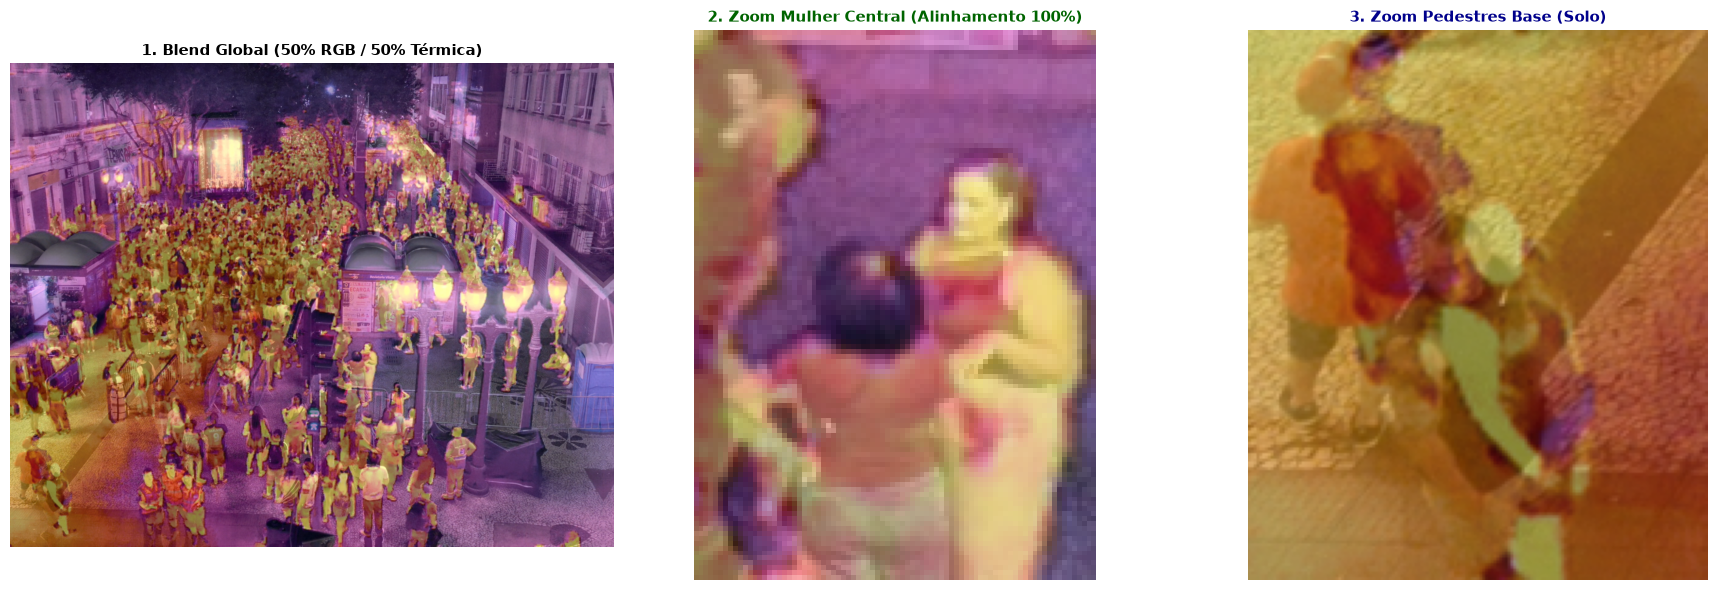

[*] Painel de auditoria visual salvo em: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/01_pre_transformacao/painel_alinhamento_multimodal.jpg


In [8]:
blend = cv2.addWeighted(img_rgb_aligned, 0.5, img_th_resized, 0.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Visualização completa
axes[0].imshow(blend)
axes[0].set_title("1. Blend Global (50% RGB / 50% Térmica)", fontsize=11, fontweight="bold")
axes[0].axis("off")

# Zoom Mulher Central
y1_m, y2_m, x1_m, x2_m = 566, 678, 699, 781
axes[1].imshow(blend[y1_m:y2_m, x1_m:x2_m])
axes[1].set_title("2. Zoom Mulher Central (Alinhamento 100%)", fontsize=11, fontweight="bold", color="darkgreen")
axes[1].axis("off")

# Zoom Pedestres Base
y1_p, y2_p, x1_p, x2_p = 786, 981, 9, 172
axes[2].imshow(blend[y1_p:y2_p, x1_p:x2_p])
axes[2].set_title("3. Zoom Pedestres Base (Solo)", fontsize=11, fontweight="bold", color="darkblue")
axes[2].axis("off")

plt.tight_layout()
audit_panel_path = OUTPUT_DIR / "painel_alinhamento_multimodal.jpg"
plt.savefig(str(audit_panel_path), dpi=150, bbox_inches="tight")
plt.show()

print(f"[*] Painel de auditoria visual salvo em: {audit_panel_path}")


## 9. Passo 7 - Exportação do Contrato de Insumos Padronizados e Metadados
Gravamos o contrato formal consumido pelo **Notebook 02** em `output/01_pre_transformacao/`:
- `rgb_preprocessed.jpg`: Imagem óptica corrigida, recortada e transladada.
- `thermal_preprocessed.jpg`: Imagem térmica equalizada com CLAHE.
- `blend_alta_precisao.jpg`: Blend 50/50 de auditoria.
- `metadata_preprocessing.json`: Telemetria detalhada da transformação.

> Para o design pattern de Data Contracts e isolamento total entre pré-processamento óptico e inferência de IA, consulte:  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md` (Decisão 07: Exportação do Contrato de Insumos Padronizado)](docs/EXPLICACAO_DECISOES_NOTEBOOK_01.md#decisao-07-exportacao-do-contrato-de-insumos-padronizado)


In [9]:
# Salvar imagens tratadas em BGR para disco
cv2.imwrite(str(OUTPUT_DIR / "rgb_preprocessed.jpg"), cv2.cvtColor(img_rgb_aligned, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_DIR / "thermal_preprocessed.jpg"), cv2.cvtColor(img_th_resized, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_DIR / "blend_alta_precisao.jpg"), cv2.cvtColor(blend, cv2.COLOR_RGB2BGR))

# Salvar metadados do contrato
metadata = {
    "etapa": "01_pre_transformacao_alinhamento",
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "imagens_originais": {
        "rgb_raw": str(raw_rgb_path.name),
        "thermal_raw": str(raw_th_path.name),
        "resolucao_rgb_raw": [w_rgb, h_rgb],
        "resolucao_thermal_raw": [w_th, h_th]
    },
    "parametros_transformacao": {
        "fov_crop_ratio": eq.fov_crop_ratio,
        "undistort_lens": eq.undistort_lens,
        "spatial_shift_pixels": [eq.shift_rgb_x, eq.shift_rgb_y],
        "thermal_clahe_clip_limit": eq.clahe_clip_limit,
        "thermal_clahe_tile_grid": list(eq.clahe_tile_grid)
    },
    "contrato_saida": {
        "resolucao_padronizada": [1280, 1024],
        "divisivel_por_32": True,
        "rgb_preprocessed": str(OUTPUT_DIR / "rgb_preprocessed.jpg"),
        "thermal_preprocessed": str(OUTPUT_DIR / "thermal_preprocessed.jpg"),
        "blend_alta_precisao": str(OUTPUT_DIR / "blend_alta_precisao.jpg"),
        "painel_alinhamento": str(audit_panel_path)
    }
}

metadata_path = OUTPUT_DIR / "metadata_preprocessing.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("=" * 65)
print("     ESTÁGIO 1 CONCLUÍDO: CONTRATO DE INSUMOS GERADO COM SUCESSO")
print("=" * 65)
print(f"1. RGB Pré-processado:     {OUTPUT_DIR / 'rgb_preprocessed.jpg'}")
print(f"2. Térmica Pré-processada: {OUTPUT_DIR / 'thermal_preprocessed.jpg'}")
print(f"3. Blend de Referência:    {OUTPUT_DIR / 'blend_alta_precisao.jpg'}")
print(f"4. Painel de Auditoria:    {audit_panel_path}")
print(f"5. Metadados do Pipeline:  {metadata_path}")
print("=" * 65)


     ESTÁGIO 1 CONCLUÍDO: CONTRATO DE INSUMOS GERADO COM SUCESSO
1. RGB Pré-processado:     /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/01_pre_transformacao/rgb_preprocessed.jpg
2. Térmica Pré-processada: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/01_pre_transformacao/thermal_preprocessed.jpg
3. Blend de Referência:    /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/01_pre_transformacao/blend_alta_precisao.jpg
4. Painel de Auditoria:    /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/01_pre_transformacao/painel_alinhamento_multimodal.jpg
5. Metadados do Pipeline:  /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/01_pre_transformacao/metadata_preprocessing.json
